In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        48   (2094, 964)   float32   


In [4]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

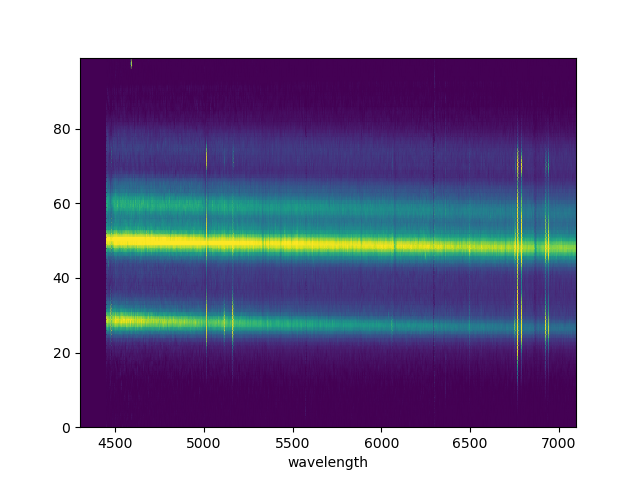

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/PSF/Real_seeing_NGC3217_1.txt")
sigma = seeing[0] / 2.35

In [7]:
l_OIII

5166.773370000001

Text(0.5, 1.0, 'H$\\alpha$')

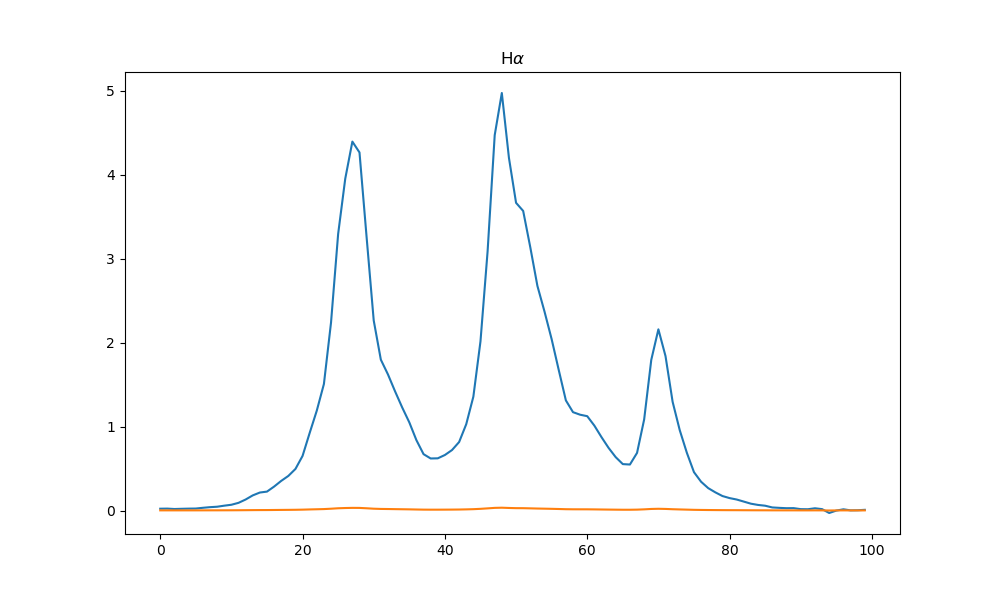

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 121.74313545245535
differential_evolution step 2: f(x)= 121.74313545245535
differential_evolution step 3: f(x)= 118.39244460525236
differential_evolution step 4: f(x)= 114.66720570555376
differential_evolution step 5: f(x)= 112.82889016637783
differential_evolution step 6: f(x)= 112.82889016637783
differential_evolution step 7: f(x)= 112.82889016637783
differential_evolution step 8: f(x)= 109.0118692500401
differential_evolution step 9: f(x)= 108.0548922257081
differential_evolution step 10: f(x)= 106.82234864294531
differential_evolution step 11: f(x)= 106.82234864294531
differential_evolution step 12: f(x)= 104.97585193745067
differential_evolution step 13: f(x)= 104.97585193745067
differential_evolution step 14: f(x)= 104.97585193745067
differential_evolution step 15: f(x)= 104.51120489157248
differential_evolution step 16: f(x)= 101.34575955036075
differential_evolution step 17: f(x)= 101.01036646316425
differential_evolution step 18: f(x)= 100.

Optimize parameters with curve fit:
Sérsic 1: I_e=1.1698, r_e=22.4740, n=0.1222, x_0=46.4523
[0.11502181 3.47576546 0.04905853 0.84328095]
1202.725971615537
1211.147024247116 0.0 1221.1466523594893 4


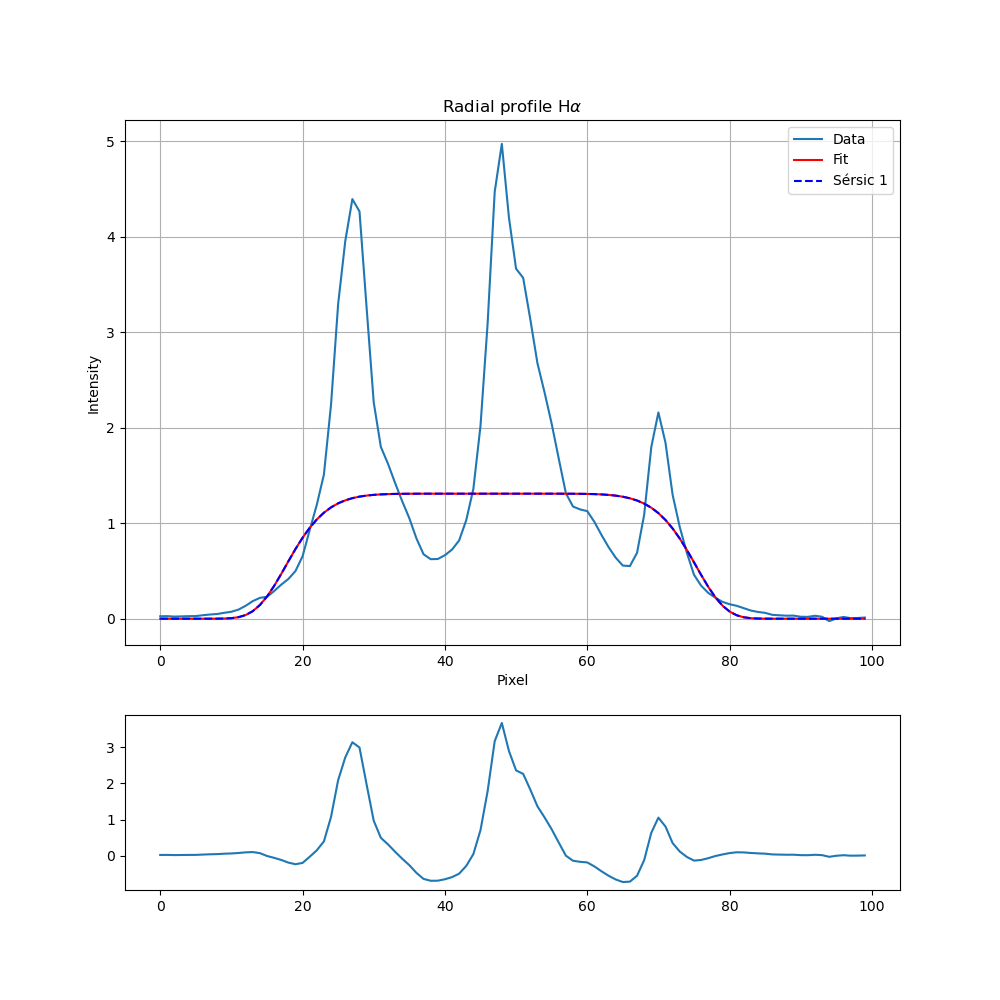

In [11]:
# Plots:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 158.24629411151582
differential_evolution step 2: f(x)= 102.66294195983967
differential_evolution step 3: f(x)= 102.66294195983967
differential_evolution step 4: f(x)= 102.66294195983967
differential_evolution step 5: f(x)= 102.66294195983967
differential_evolution step 6: f(x)= 89.6335787617677
differential_evolution step 7: f(x)= 78.85105517748482
differential_evolution step 8: f(x)= 57.30695223269922
differential_evolution step 9: f(x)= 57.30695223269922
differential_evolution step 10: f(x)= 54.34059824959352
differential_evolution step 11: f(x)= 54.34059824959352
differential_evolution step 12: f(x)= 54.34059824959352
differential_evolution step 13: f(x)= 42.70650126354799
differential_evolution step 14: f(x)= 42.70650126354799
differential_evolution step 15: f(x)= 42.70650126354799
differential_evolution step 16: f(x)= 42.70650126354799
differential_evolution step 17: f(x)= 33.22253279481652
differential_evolution step 18: f(x)= 33.222532794816

Optimize parameters with curve fit:
Sérsic 1: I_e=1.2562, r_e=4.3757, n=0.8238, x_0=26.9884
Sérsic 2: I_e=0.3744, r_e=19.9322, n=1.5266, x_0=49.8938
[0.32318721 0.64051849 0.19581735 0.23478605 0.08643713 3.0536605
 0.17710521 0.3062948 ]
371.88897095659917
389.47138853901674 371.88897095659917 408.7303324445039 8


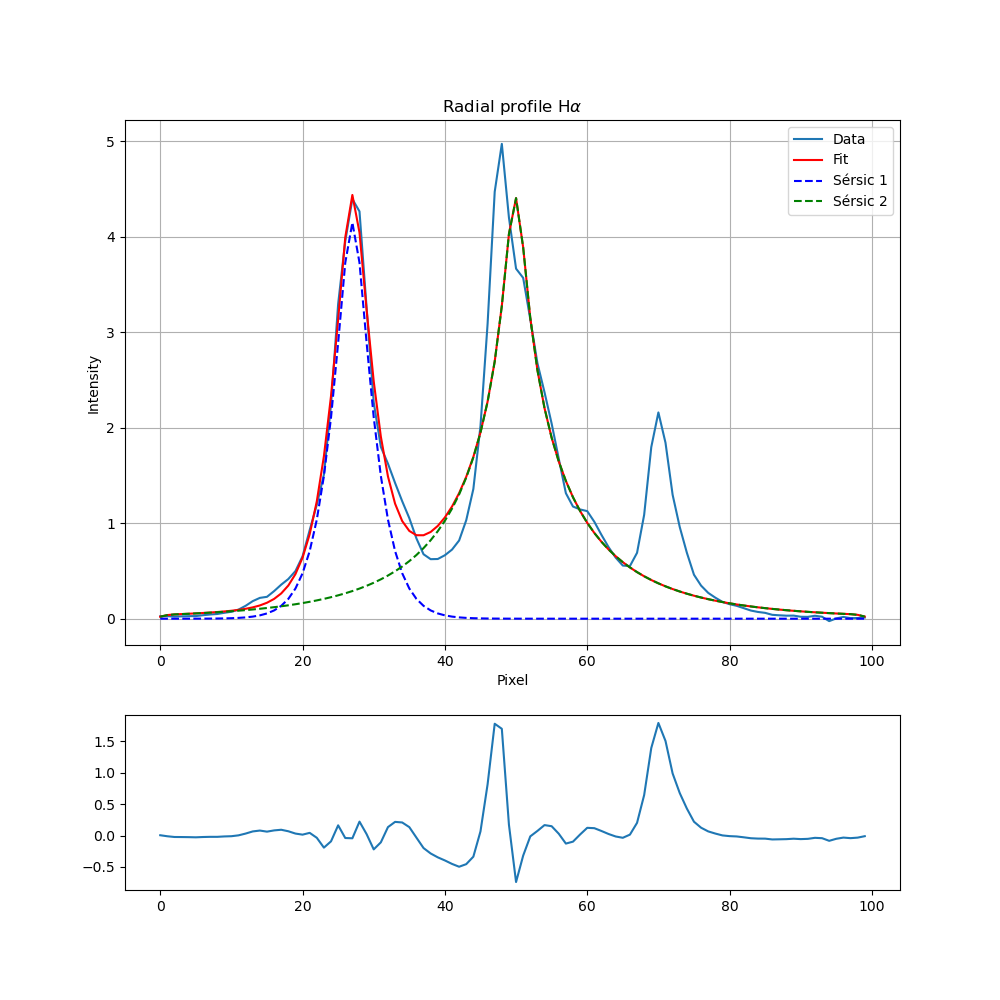

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 3941.5205074975156
differential_evolution step 2: f(x)= 3648.3587335073394
differential_evolution step 3: f(x)= 3648.3587335073394
differential_evolution step 4: f(x)= 1902.9814516207489
differential_evolution step 5: f(x)= 283.4978746659589
differential_evolution step 6: f(x)= 130.36588661345107
differential_evolution step 7: f(x)= 130.36588661345107
differential_evolution step 8: f(x)= 130.36588661345107
differential_evolution step 9: f(x)= 96.71324624261004
differential_evolution step 10: f(x)= 96.71324624261004
differential_evolution step 11: f(x)= 61.97884800988707
differential_evolution step 12: f(x)= 61.97884800988707
differential_evolution step 13: f(x)= 61.97884800988707
differential_evolution step 14: f(x)= 61.97884800988707
differential_evolution step 15: f(x)= 59.45291692911612
differential_evolution step 16: f(x)= 47.64072052414837
differential_evolution step 17: f(x)= 38.656205962086894
differential_evolution step 18: f(x)= 34.16559291

Optimize parameters with curve fit:
Sérsic 1: I_e=0.8855, r_e=6.4375, n=1.0821, x_0=27.1734
Sérsic 2: I_e=1.1950, r_e=7.1722, n=0.8342, x_0=49.8374
Sérsic 3: I_e=0.1616, r_e=9.6533, n=1.7415, x_0=70.1838
[0.11649754 0.50218399 0.10185893 0.1262569  0.15748057 0.58470108
 0.09199536 0.15176224 0.08309046 2.89714153 0.56726628 0.09117861]
104.17933021039194
131.76553710694364 104.17933021039194 159.44137244224905 12


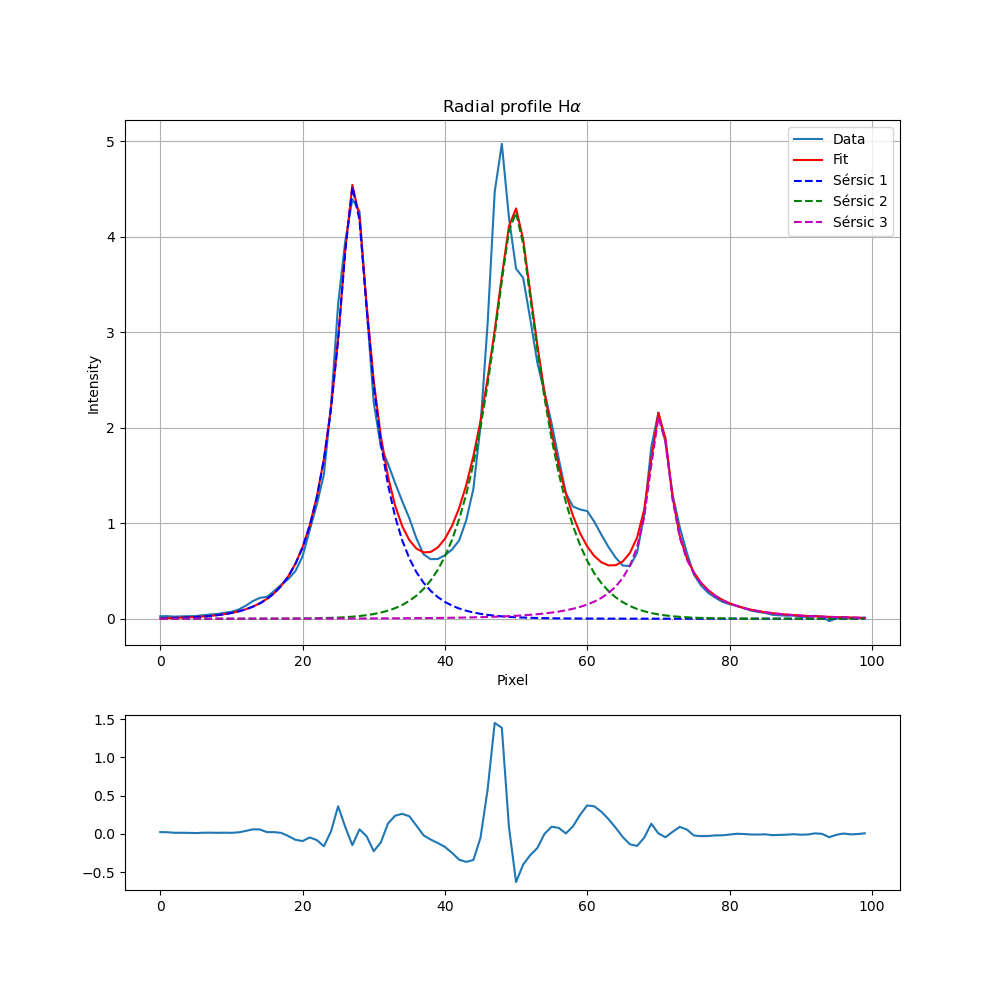

In [15]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 58354.47922165476
differential_evolution step 2: f(x)= 4026.938760795517
differential_evolution step 3: f(x)= 4026.938760795517
differential_evolution step 4: f(x)= 2592.1324952384716
differential_evolution step 5: f(x)= 2592.1324952384716
differential_evolution step 6: f(x)= 2592.1324952384716
differential_evolution step 7: f(x)= 2486.359865193909
differential_evolution step 8: f(x)= 2486.359865193909
differential_evolution step 9: f(x)= 2486.359865193909
differential_evolution step 10: f(x)= 875.7397196632496
differential_evolution step 11: f(x)= 875.7397196632496
differential_evolution step 12: f(x)= 875.7397196632496
differential_evolution step 13: f(x)= 875.7397196632496
differential_evolution step 14: f(x)= 875.7397196632496
differential_evolution step 15: f(x)= 875.7397196632496
differential_evolution step 16: f(x)= 147.3835826684953
differential_evolution step 17: f(x)= 147.3835826684953
differential_evolution step 18: f(x)= 147.383582668495

Optimize parameters with curve fit:
Sérsic 1: I_e=0.8017, r_e=6.6819, n=1.1446, x_0=27.1696
Sérsic 2: I_e=1.3691, r_e=1.8505, n=0.7038, x_0=47.6453
Sérsic 3: I_e=0.1713, r_e=6.8497, n=1.7446, x_0=70.3542
Sérsic 4: I_e=0.5265, r_e=11.6205, n=1.1082, x_0=51.6856
[0.05992646 0.38294196 0.05794534 0.06450491 0.32582762 0.33350492
 0.1884294  0.10908369 0.07255436 2.58097045 0.3138767  0.08203129
 0.14047206 2.31555546 0.1497902  0.34021761]
25.51703034983078
64.07124721730065 25.51703034983078 99.19975332564024 16


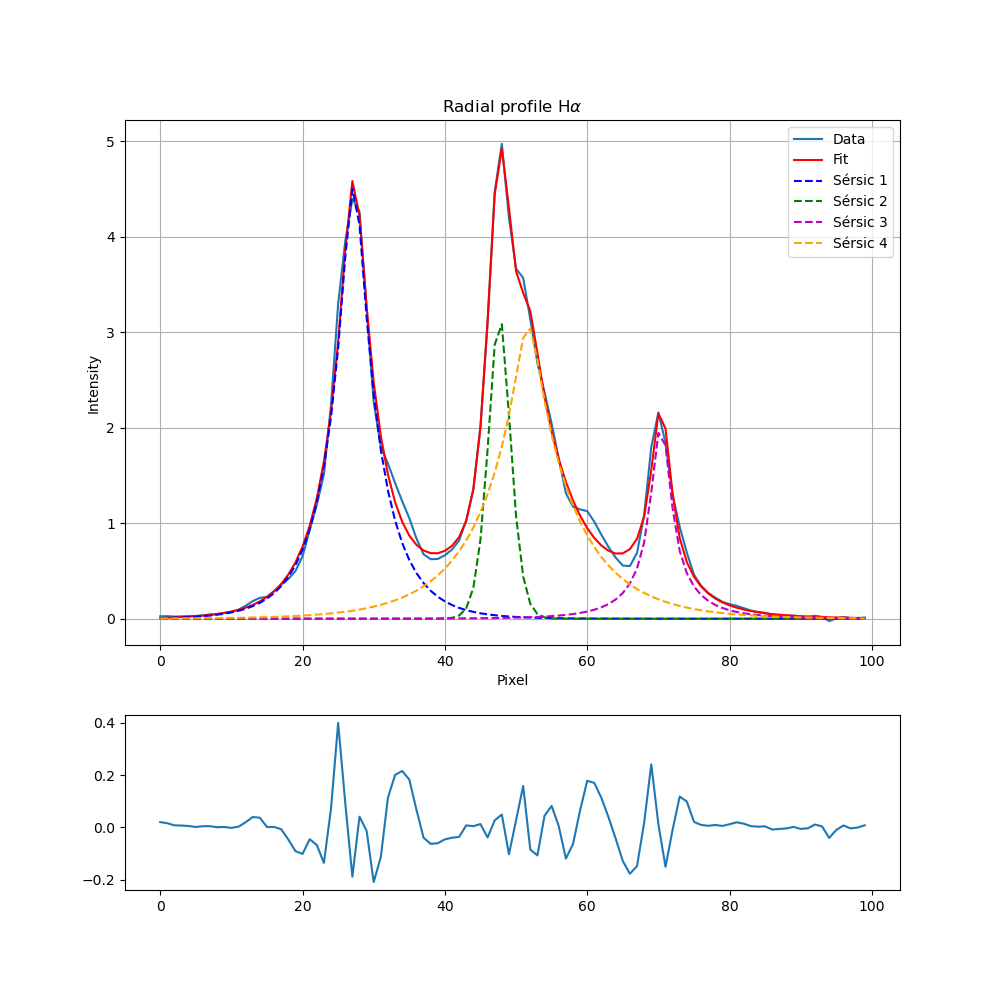

In [17]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 8432.56987608014
differential_evolution step 2: f(x)= 8432.56987608014
differential_evolution step 3: f(x)= 8432.56987608014
differential_evolution step 4: f(x)= 8205.600113455175
differential_evolution step 5: f(x)= 5350.75282104686
differential_evolution step 6: f(x)= 5350.75282104686
differential_evolution step 7: f(x)= 2721.991461764326
differential_evolution step 8: f(x)= 748.4829732468683
differential_evolution step 9: f(x)= 748.4829732468683
differential_evolution step 10: f(x)= 748.4829732468683
differential_evolution step 11: f(x)= 748.4829732468683
differential_evolution step 12: f(x)= 486.60011866691184
differential_evolution step 13: f(x)= 486.60011866691184
differential_evolution step 14: f(x)= 486.60011866691184
differential_evolution step 15: f(x)= 486.60011866691184
differential_evolution step 16: f(x)= 486.60011866691184
differential_evolution step 17: f(x)= 486.60011866691184
differential_evolution step 18: f(x)= 100.15226133821169

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [8.92353734e-01 6.29584178e+00 1.07494966e+00 2.71185811e+01
 9.58669508e-01 1.87363741e+00 9.76519625e-01 4.75565468e+01
 3.48527098e-02 2.41498645e+01 2.91625343e+00 7.01872065e+01
 6.25236035e-01 1.00653528e+01 1.03331483e+00 5.12132519e+01
 2.28532228e-01 4.65929807e-02 7.48743343e+00 6.06246401e+01]
Chi quadro minimo: 0.7398207533790055


Optimize parameters with curve fit:
Sérsic 1: I_e=0.7881, r_e=7.0172, n=1.1564, x_0=27.2268
Sérsic 2: I_e=1.2068, r_e=1.5661, n=0.7623, x_0=47.4980
Sérsic 3: I_e=0.1635, r_e=8.4440, n=1.7677, x_0=70.3151
Sérsic 4: I_e=0.8085, r_e=8.3012, n=0.9054, x_0=51.0317
Sérsic 5: I_e=0.2534, r_e=1.7561, n=0.1000, x_0=60.8719
[0.049518   0.26611286 0.04867155 0.05982244 0.43971617 0.45245416
 0.30287792 0.10506094 0.0353414  1.1286968  0.1711184  0.0776958
 0.16137235 0.9924505  0.0995996  0.34674311 0.9308213  7.681758
 1.27231885 0.35055943]
21.438875443746525
72.07178683615159 21.438875443746525 113.54227916350837 20


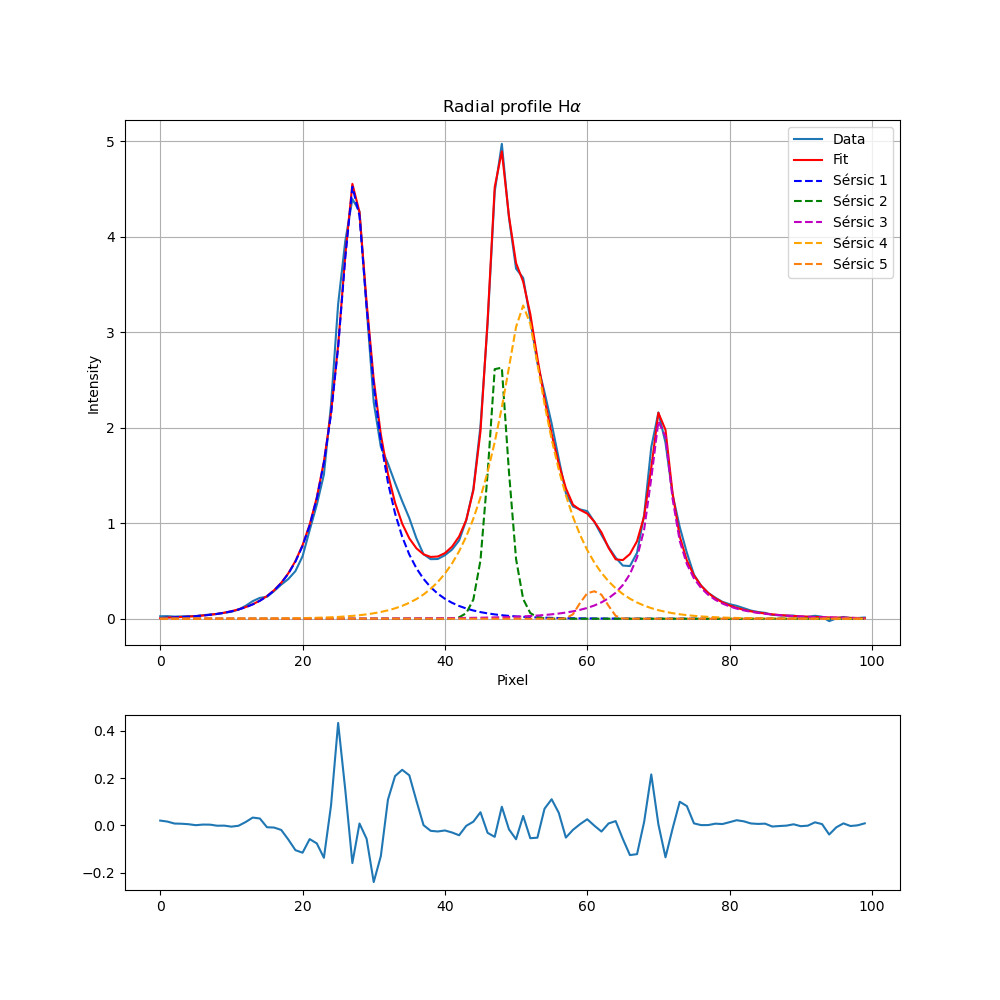

In [23]:
# Plots:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (26, 28),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (46, 48),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (69, 71),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 52), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (59, 61)
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, 
                                         sigma = radial_profile_error_HA, maxfev = 10000, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 74105.8976503894
differential_evolution step 2: f(x)= 20263.34153643399
differential_evolution step 3: f(x)= 20263.34153643399
differential_evolution step 4: f(x)= 20263.34153643399
differential_evolution step 5: f(x)= 20263.34153643399
differential_evolution step 6: f(x)= 20263.34153643399
differential_evolution step 7: f(x)= 12800.62650550578
differential_evolution step 8: f(x)= 5524.813927514162
differential_evolution step 9: f(x)= 5524.813927514162
differential_evolution step 10: f(x)= 5524.813927514162
differential_evolution step 11: f(x)= 5524.813927514162
differential_evolution step 12: f(x)= 5524.813927514162
differential_evolution step 13: f(x)= 2228.771827098002
differential_evolution step 14: f(x)= 2228.771827098002
differential_evolution step 15: f(x)= 2228.771827098002
differential_evolution step 16: f(x)= 2228.771827098002
differential_evolution step 17: f(x)= 2228.771827098002
differential_evolution step 18: f(x)= 2228.771827098002
di

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\3123596373.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.6807, r_e=7.0877, n=1.2117, x_0=27.0234
Sérsic 2: I_e=0.0327, r_e=21.0147, n=0.0281, x_0=44.0513
Sérsic 3: I_e=0.1501, r_e=8.7956, n=1.4487, x_0=70.9051
Sérsic 4: I_e=1.3288, r_e=2.1253, n=0.7300, x_0=47.7052
Sérsic 5: I_e=0.6665, r_e=6.7578, n=0.8640, x_0=52.0214
Sérsic 6: I_e=0.0993, r_e=2.9503, n=2.0441, x_0=69.5649
[5.50965817e-02 2.97131910e-01 5.61159324e-02 7.93131895e-02
 1.88604525e-01 9.42165964e-01 3.30163173e-02 5.74606720e-01
 1.91485618e-01 1.71169574e+00 5.26084478e-01 6.79209920e-01
 2.53481987e-01 2.96640904e-01 1.36112870e-01 1.05062399e-01
 1.88712625e-01 1.51720471e+00 1.73204603e-01 4.13889884e-01
 1.61223073e+00 3.45886716e+01 2.03410649e+01 8.04811692e-02]
15.243345209504918
79.24334520950492 15.243345209504918 125.76742967321913 24


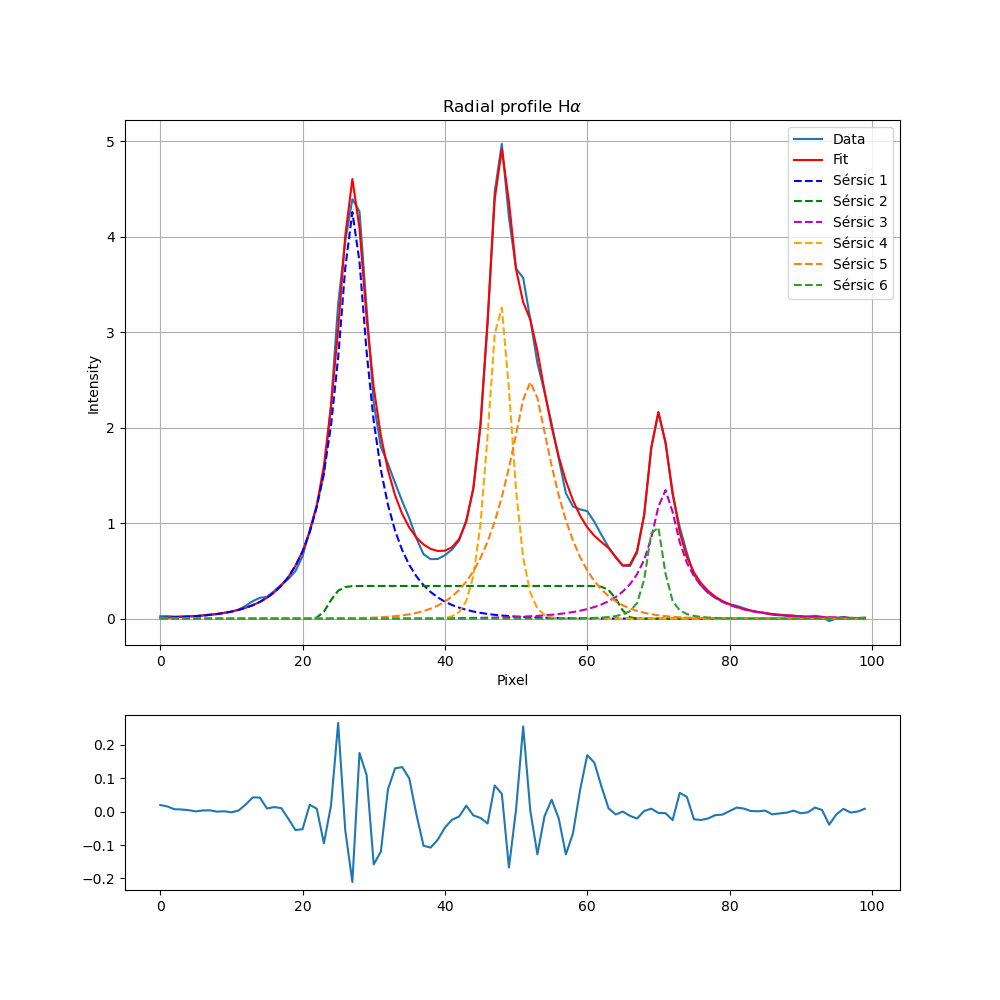

In [25]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (65, 75),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 293170.69578386913
differential_evolution step 2: f(x)= 140766.88264954972
differential_evolution step 3: f(x)= 64781.88336032384
differential_evolution step 4: f(x)= 64781.88336032384
differential_evolution step 5: f(x)= 64781.88336032384
differential_evolution step 6: f(x)= 64781.88336032384
differential_evolution step 7: f(x)= 39968.99184454725
differential_evolution step 8: f(x)= 39968.99184454725
differential_evolution step 9: f(x)= 39968.99184454725
differential_evolution step 10: f(x)= 19738.380732775313
differential_evolution step 11: f(x)= 19738.380732775313
differential_evolution step 12: f(x)= 19738.380732775313
differential_evolution step 13: f(x)= 11777.514457937243
differential_evolution step 14: f(x)= 11777.514457937243
differential_evolution step 15: f(x)= 4265.7776348208945
differential_evolution step 16: f(x)= 4265.7776348208945
differential_evolution step 17: f(x)= 2841.4457763002097
differential_evolution step 18: f(x)= 2841.4457

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10724\2732296734.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.9430, r_e=1.6570, n=0.8076, x_0=27.8055
Sérsic 2: I_e=0.3204, r_e=8.1175, n=1.4265, x_0=25.5731
Sérsic 3: I_e=0.2067, r_e=7.9952, n=1.6043, x_0=70.2047
Sérsic 4: I_e=1.3994, r_e=5.6626, n=0.5879, x_0=50.6411
Sérsic 5: I_e=0.3965, r_e=2.0754, n=0.2959, x_0=60.9678
Sérsic 6: I_e=0.8940, r_e=1.5102, n=0.9152, x_0=47.5100
Sérsic 7: I_e=0.2280, r_e=8.0240, n=0.9929, x_0=32.4486
[0.90683821 1.04023728 0.66986107 0.15321666 0.05487291 1.42245096
 0.16311473 0.28048824 0.01979726 0.48228698 0.07487235 0.04319046
 0.23116799 0.58655048 0.07735294 0.36489247 0.07008281 0.33217966
 0.16362542 0.21230193 0.46478146 0.69498219 0.43249459 0.05619766
 0.14550599 5.09024814 0.35646084 0.76892087]
6.440240295246948
85.31347973186666 6.440240295246948 135.38500550291351 28


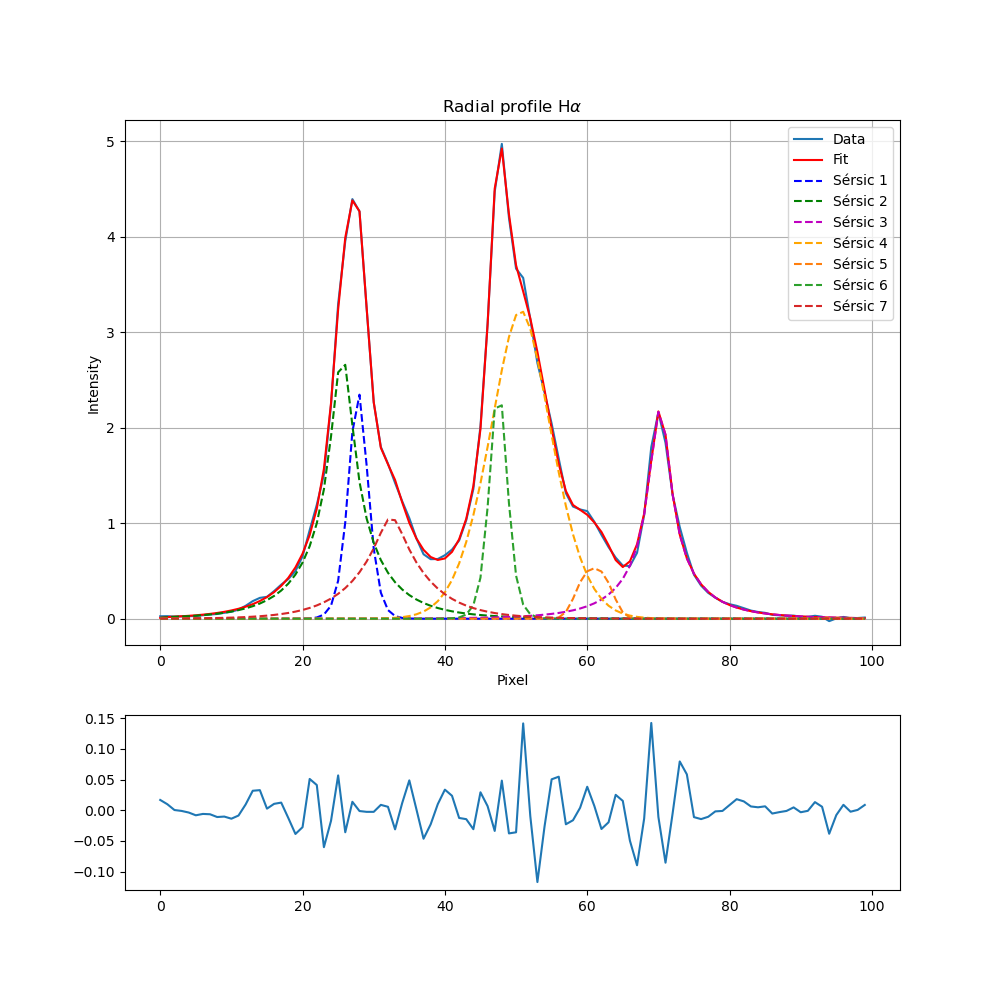

In [27]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

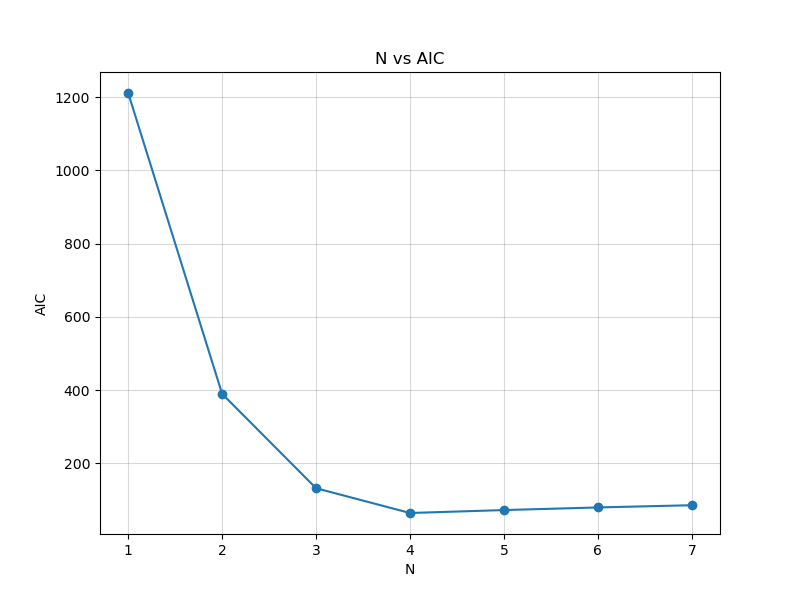

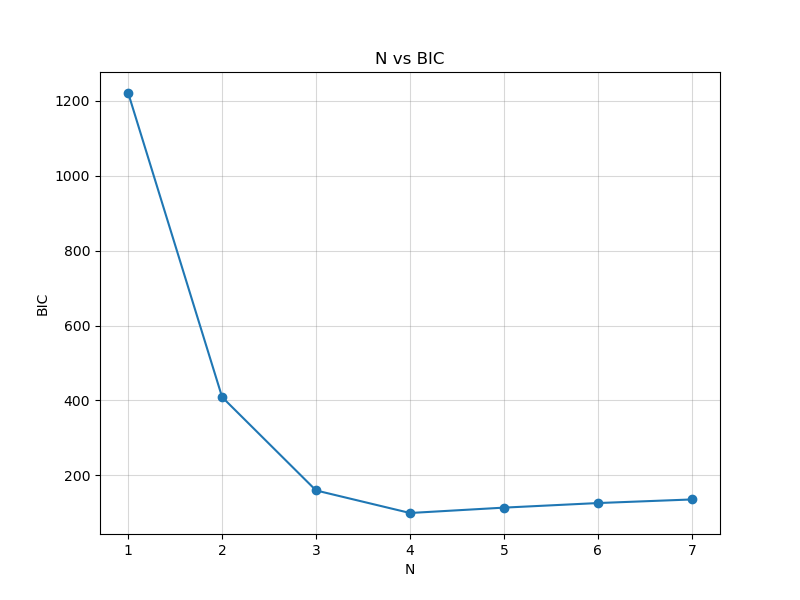

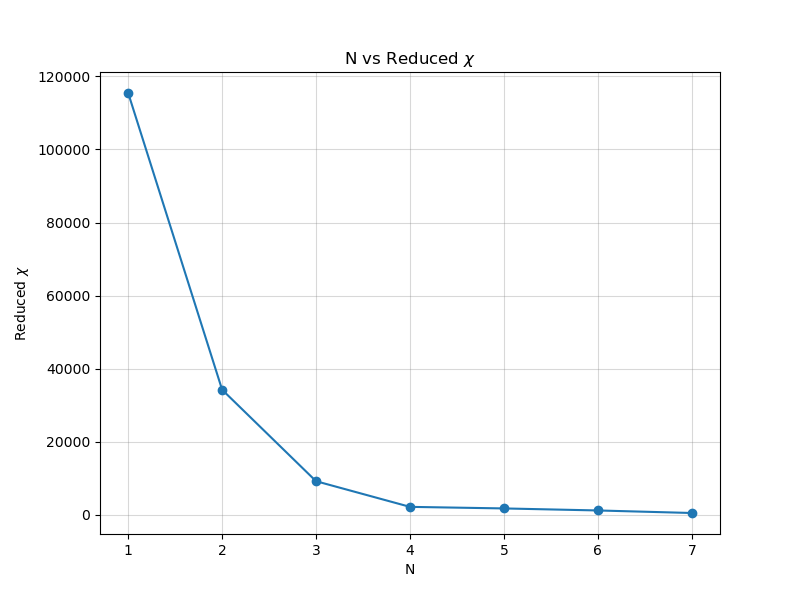

In [28]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

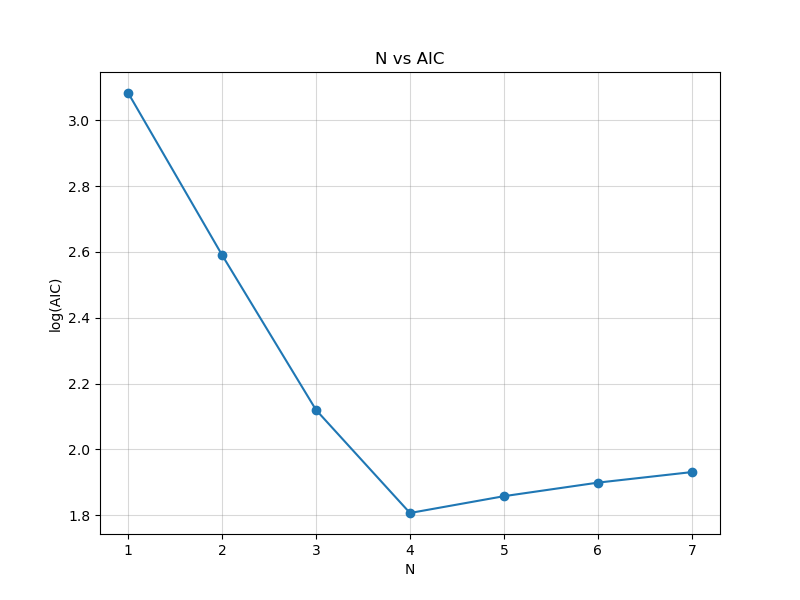

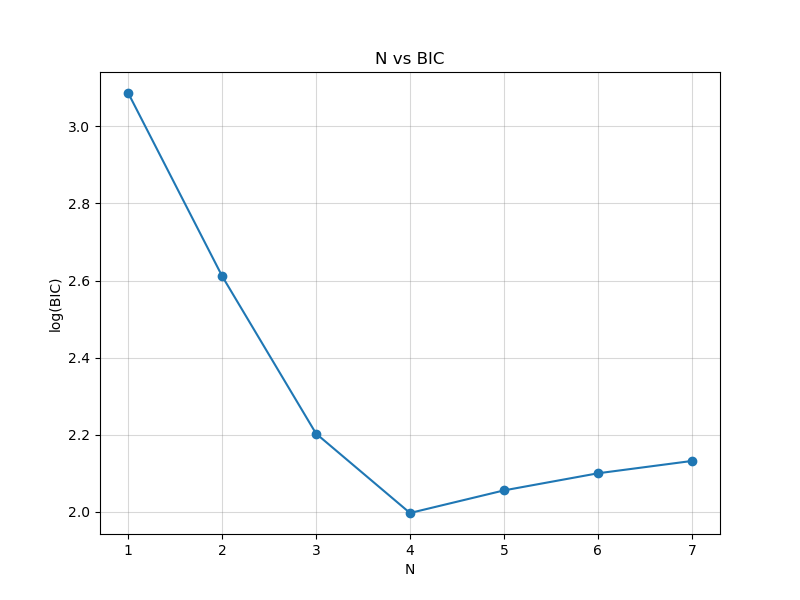

In [29]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')